# SRQ3: Algorithmic Homogeneity vs. Comment-Section Homogeneity — Regression

OLS regression of comment-section homogeneity (`comment_EI`) on algorithmic recommendation homogeneity (`algo_EI`), with camp (Right vs. Neutral) as a moderator. Produces Table 5, Table D2, and Figure D2 in the paper.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import matplotlib.pyplot as plt

In [23]:
# Table 5: comment_EI ~ algo_EI, with camp control and interaction
comment_df_check = pd.read_csv('video_comment_ei_index_main_origin_hun.csv')
comment_df_check = comment_df_check[[c for c in comment_df_check.columns if not c.startswith('Unnamed')]].copy()
algo_df_check = pd.read_csv('video_recom_ei_index.csv')

comment_df_check['anti_total'] = (comment_df_check['Anti-immigration_internal']
                                   + comment_df_check['Anti-immigration_external'])
comment_df_check['nonanti_total'] = (comment_df_check['Non-anti-immigration_internal']
                                      + comment_df_check['Non-anti-immigration_external'])
comment_df_check['anti_share'] = (comment_df_check['anti_total']
                                   / (comment_df_check['anti_total'] + comment_df_check['nonanti_total']))
comment_df_check['log_nodes'] = np.log(comment_df_check['nodes'])

merged_check = pd.merge(
    comment_df_check[['video_id', 'global_EI', 'video_stance', 'anti_share', 'log_nodes']].rename(
        columns={'global_EI': 'comment_EI'}),
    algo_df_check[['video_id', 'EI_index']].rename(columns={'EI_index': 'algo_EI'}),
    on='video_id', how='inner'
).dropna(subset=['comment_EI', 'algo_EI', 'log_nodes', 'anti_share', 'video_stance']).copy()

# Right = 1, Neutral = 0 (reference)
merged_check['right_dummy'] = (merged_check['video_stance'] == 'Right').astype(int)
merged_check['algo_EI_x_Right'] = merged_check['algo_EI'] * merged_check['right_dummy']

print(f"样本量: {len(merged_check)}")
print(merged_check['video_stance'].value_counts())
print()

y = merged_check['comment_EI']

# Model 1: pooled baseline
X_full = sm.add_constant(merged_check[['algo_EI', 'log_nodes', 'anti_share']])
model_full = sm.OLS(y, X_full).fit()

print("===== 问题1: Pooled 全模型 — 是否存在总体关系? =====")
print(model_full.summary())
print()

# Model 2 / 3: + camp control, + interaction
X_no_int = sm.add_constant(merged_check[['algo_EI', 'right_dummy', 'log_nodes', 'anti_share']])
model_no_interaction = sm.OLS(y, X_no_int).fit()

X_int = sm.add_constant(merged_check[['algo_EI', 'right_dummy', 'algo_EI_x_Right', 'log_nodes', 'anti_share']])
model_interaction = sm.OLS(y, X_int).fit()

f_stat, f_pval, df_diff = model_interaction.compare_f_test(model_no_interaction)
print(f"交互项联合显著性 F 检验: F({df_diff:.0f}, {int(model_interaction.df_resid)}) = {f_stat:.3f}, p = {f_pval:.3f}")
print()

comparison_table = summary_col(
    [model_no_interaction, model_interaction],
    model_names=['No Interaction', 'With Interaction'],
    stars=True,
    float_format='%0.3f',
    info_dict={'N': lambda x: f"{int(x.nobs)}"}
)
print("===== 问题2: 无交互 vs 有交互 对比表 =====")
print(comparison_table)

样本量: 54
video_stance
Right         29
Mainstream    25
Name: count, dtype: int64

===== 问题1: Pooled 全模型 — 是否存在总体关系? =====
                            OLS Regression Results                            
Dep. Variable:             comment_EI   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     25.07
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           4.84e-10
Time:                        02:35:05   Log-Likelihood:                0.55152
No. Observations:                  54   AIC:                             6.897
Df Residuals:                      50   BIC:                             14.85
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------

In [29]:
from docx import Document
from docx.shared import Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement


def set_cell_border(cell, **kwargs):
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()
    tcBorders = tcPr.find(qn('w:tcBorders'))
    if tcBorders is None:
        tcBorders = OxmlElement('w:tcBorders')
        tcPr.append(tcBorders)
    for edge, edge_kwargs in kwargs.items():
        tag = f'w:{edge}'
        el = tcBorders.find(qn(tag))
        if el is None:
            el = OxmlElement(tag)
            tcBorders.append(el)
        for k, v in edge_kwargs.items():
            el.set(qn(f'w:{k}'), str(v))

def row_top_border(row):
    for cell in row.cells:
        set_cell_border(cell, top={'sz': 12, 'val': 'single', 'color': '000000'})

def row_bottom_border(row):
    for cell in row.cells:
        set_cell_border(cell, bottom={'sz': 12, 'val': 'single', 'color': '000000'})

def clear_all_borders(table):
    for row in table.rows:
        for cell in row.cells:
            set_cell_border(cell, top={'sz': 0, 'val': 'nil'}, bottom={'sz': 0, 'val': 'nil'},
                             left={'sz': 0, 'val': 'nil'}, right={'sz': 0, 'val': 'nil'})

def set_font(run, size=10.5, bold=False, italic=False, name="Times New Roman"):
    run.font.name = name
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.italic = italic
    rPr = run._element.get_or_add_rPr()
    rFonts = rPr.find(qn('w:rFonts'))
    if rFonts is None:
        rFonts = OxmlElement('w:rFonts')
        rPr.append(rFonts)
    rFonts.set(qn('w:eastAsia'), name)

def add_cell_text(cell, text, size=10.5, bold=False, italic=False, align="left"):
    cell.text = ""
    p = cell.paragraphs[0]
    p.alignment = {"left": WD_ALIGN_PARAGRAPH.LEFT, "center": WD_ALIGN_PARAGRAPH.CENTER}[align]
    run = p.add_run(text)
    set_font(run, size=size, bold=bold, italic=italic)
    return p


def save_three_line_table(df, title, out_path, notes=None, first_col_width=6.0, col_width=2.8,
                            first_col_label="Variable"):
    """Save a DataFrame (index as the leftmost row-label column) as a Times New Roman
    three-line-table Word document, matching the Table 1 style."""
    doc = Document()
    section = doc.sections[0]
    section.left_margin = Cm(2.2)
    section.right_margin = Cm(2.2)

    title_p = doc.add_paragraph()
    title_run = title_p.add_run(title)
    set_font(title_run, size=11, bold=True)

    n_cols = len(df.columns) + 1
    n_rows = len(df) + 1
    table = doc.add_table(rows=n_rows, cols=n_cols)
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.autofit = False
    widths = [Cm(first_col_width)] + [Cm(col_width)] * len(df.columns)
    for row in table.rows:
        for cell, w in zip(row.cells, widths):
            cell.width = w
    clear_all_borders(table)

    add_cell_text(table.rows[0].cells[0], first_col_label, bold=True, align="left")
    for c, col in enumerate(df.columns, start=1):
        add_cell_text(table.rows[0].cells[c], str(col), bold=True, align="center")
    row_top_border(table.rows[0])
    row_bottom_border(table.rows[0])

    for r, (idx, row_vals) in enumerate(df.iterrows(), start=1):
        add_cell_text(table.rows[r].cells[0], str(idx), align="left")
        for c, val in enumerate(row_vals, start=1):
            add_cell_text(table.rows[r].cells[c], str(val), align="center")
    row_bottom_border(table.rows[-1])

    if notes:
        notes_p = doc.add_paragraph()
        notes_p.paragraph_format.space_before = Pt(6)
        run = notes_p.add_run(notes)
        set_font(run, size=9, italic=True)

    doc.save(out_path)
    return out_path

In [33]:
# Table D2: descriptive statistics for the Table 5 variables
desc_vars = ["comment_EI", "algo_EI", "right_dummy", "log_nodes", "anti_share"]

desc_stats_raw = pd.DataFrame({
    "N": merged_check[desc_vars].count().astype(int),
    "Mean": merged_check[desc_vars].mean(),
    "SD": merged_check[desc_vars].std(),
    "Min": merged_check[desc_vars].min(),
    "Max": merged_check[desc_vars].max(),
})

# format as strings first so N doesn't get upcast to float ("54.0") by iterrows()
desc_stats = pd.DataFrame({
    "N": desc_stats_raw["N"].map(lambda x: f"{x:d}"),
    "Mean": desc_stats_raw["Mean"].map(lambda x: f"{x:.3f}"),
    "SD": desc_stats_raw["SD"].map(lambda x: f"{x:.3f}"),
    "Min": desc_stats_raw["Min"].map(lambda x: f"{x:.3f}"),
    "Max": desc_stats_raw["Max"].map(lambda x: f"{x:.3f}"),
}, index=desc_stats_raw.index)

label_map = {
    "comment_EI": "Comment-Section E-I Index (comment_EI)",
    "algo_EI": "Algorithmic E-I Index (algo_EI)",
    "right_dummy": "Right (1 = Right-wing, 0 = Neutral)",
    "log_nodes": "Log(Comment Network Size)",
    "anti_share": "Anti-immigration Comment Share",
}
desc_stats.index = [label_map[v] for v in desc_stats.index]

print(f"===== Table 5 变量描述性统计 (N = {len(merged_check)}) =====")
print(desc_stats_raw.round(3))

path_e1 = save_three_line_table(
    desc_stats,
    title="Table E1. Descriptive Statistics for the Variables Used in Table 5",
    out_path="../SRQ3 Regression/TableE1_descriptive_statistics.docx",
    first_col_width=7.0, col_width=2.2,
    first_col_label="Variable",
    notes=("Notes: N = 54. right_dummy, log_nodes, and anti_share are the covariates entered in "
           "the Table 5 models; for the binary variable right_dummy, Mean is the proportion of "
           "right-wing videos in the sample."),
)
print("\nsaved:", path_e1)

===== Table 5 变量描述性统计 (N = 54) =====
              N   Mean     SD    Min    Max
comment_EI   54  0.018  0.383 -0.838  0.559
algo_EI      54 -0.027  0.510 -1.000  1.000
right_dummy  54  0.537  0.503  0.000  1.000
log_nodes    54  5.458  0.846  3.219  6.733
anti_share   54  0.729  0.191  0.246  0.959

saved: ../SRQ3 Regression/TableE1_descriptive_statistics.docx


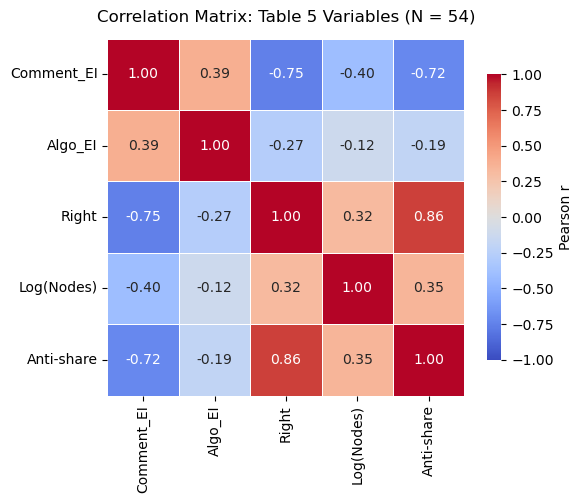

saved: ../SRQ3 Regression/FigureE1_correlation_heatmap_table5.png


In [34]:
# Figure D2: correlation heatmap for the Table 5 variables
try:
    import seaborn as sns
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", "seaborn"])
    import seaborn as sns

heatmap_vars = ["comment_EI", "algo_EI", "right_dummy", "log_nodes", "anti_share"]
heatmap_labels = {
    "comment_EI": "Comment_EI",
    "algo_EI": "Algo_EI",
    "right_dummy": "Right",
    "log_nodes": "Log(Nodes)",
    "anti_share": "Anti-share",
}

corr_e1 = merged_check[heatmap_vars].corr().rename(index=heatmap_labels, columns=heatmap_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_e1,
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Pearson r", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlation Matrix: Table 5 Variables (N = 54)", fontsize=12, pad=12)
plt.tight_layout()

out_path_e1 = "../SRQ3 Regression/FigureE1_correlation_heatmap_table5.png"
plt.savefig(out_path_e1, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", out_path_e1)